# Section 5 — Working with Generative AI: Basics and Best Practices

A hands-on tour of how large language models work, how to access them via API, and how to prompt them well — written for actuaries.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/05_genai_basics_best_practices/05_genai_basics_best_practices.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).

This notebook accompanies Section 5 of the seminar. We start by opening up an actual (small) language model on your laptop so you can see what "next-token prediction" really means, then move to cloud-served frontier models via the OpenAI Responses API. By the end you will have prompted, parameter-tuned, and cost-estimated an LLM on three small actuarial tasks, and you will have a clear-eyed view of what LLMs can and cannot reliably do.

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. From web chat to API — why it matters](#1-from-web-chat-to-api--why-it-matters)
- [2. How an LLM actually works — a hands-on look](#2-how-an-llm-actually-works--a-hands-on-look)
- [3. The provider and model landscape](#3-the-provider-and-model-landscape)
- [4. Accessing LLMs via API](#4-accessing-llms-via-api)
- [5. API parameters and how they shape output](#5-api-parameters-and-how-they-shape-output)
- [6. Prompt engineering techniques](#6-prompt-engineering-techniques)
- [7. Honest framing — what LLMs get wrong](#7-honest-framing--what-llms-get-wrong)
- [8. Concrete token cost — a quick estimator](#8-concrete-token-cost--a-quick-estimator)
- [9. How do you even test this thing? — evaluation sketch](#9-how-do-you-even-test-this-thing--evaluation-sketch)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)

## Learning objectives

By the end of this notebook you will be able to:

- Explain the working principle of a large language model (next-token prediction over a learned probability distribution) and demonstrate it on a real, small open-weights model on your own machine.
- Compare today's main LLM providers and models on the dimensions that matter in practice: capability, speed, cost, context window, tool use, and multimodality.
- Choose between cloud APIs and locally hosted models for a given actuarial workload, with a clear-eyed view of latency, cost, data residency, and confidentiality.
- Call a frontier LLM through its API, configure the parameters that actually move the needle (`instructions`, `temperature`), and read the response object.
- Apply zero-shot, few-shot, and chain-of-thought prompting — plus role/delimiter and output-format patterns — to three small actuarial tasks, and judge each prompt's outputs honestly.

## Setup

The cell below detects whether you are running on Google Colab. On Colab it installs the section's pinned dependencies; on a local install it assumes you have already done `pip install -r notebooks/05_genai_basics_best_practices/requirements.txt` inside your virtual environment.

For the cloud cells we use the OpenAI Responses API. Copy `.env.example` to `.env` in this folder and paste your `OPENAI_API_KEY`. If you do not have a key, every cloud cell skips gracefully — the local GPT-2 demo, the embedding viz, the attention viz, the comparison table, the limitations, the cost estimator, and the evaluation sketch all run without one.

> **Note.** The local GPT-2 demo downloads about 500 MB of model weights to the Hugging Face cache (typically `~/.cache/huggingface`) on first run. Subsequent runs use the cache.

In [1]:
# Detect whether we are running on Google Colab (this changes how we install deps).
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# On Colab, install this section's pinned dependencies straight from the repo.
if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/05_genai_basics_best_practices/requirements.txt

# Standard-library imports
import os
import base64

# Third-party scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fix the random seed so re-runs are reproducible.
SEED = 42
np.random.seed(SEED)

# Load the OpenAI API key from a local .env file, in two complementary steps:
#   1) load_dotenv() reads the .env file in this folder (if present) and copies
#      its entries into the process environment. On Colab/CI there is usually no
#      .env, so this simply does nothing.
#   2) os.environ.get() then reads the key back out of that environment.
# The two calls are NOT redundant: the first populates the environment, the
# second retrieves one value from it.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # python-dotenv not installed -> just use whatever is already in the environment

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
HAS_OPENAI_KEY = bool(OPENAI_API_KEY)

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")
print(f"OpenAI key detected: {HAS_OPENAI_KEY}.")
if not HAS_OPENAI_KEY:
    print("  -> Cloud cells will skip gracefully. Local cells still run.")

Setup complete. Environment: local.
OpenAI key detected: True.


We reuse the same colour palette as the earlier section notebooks so figures stay visually consistent across the seminar.

In [2]:
# Seminar-wide colour palette — kept identical across all section notebooks
# so figures look consistent from one section to the next.
PRIMARY      = "#1F3A6E"      # Navy blue
ACCENT_RED   = "#C0504D"      # Rust
ACCENT_GREEN = "#4E7C59"      # Forest
GRAY_TEXT    = "#404040"      # Dark gray

# Register the palette as the default seaborn/matplotlib theme.
sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

# Directory for saved figures (created on first use).
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

## 1. From Web Chat to API — Why It Matters

You have probably used an LLM through a web chat interface — ChatGPT, Claude, Gemini. The conversation feels natural and the answers feel impressive. But the chat interface is a *consumer product*. Building an actuarial workflow on top of LLMs means moving from the chat box to the **API**.

The shift matters for four reasons:

- **Automation.** A claims-handling email or a policy-extraction job runs the same prompt thousands of times. A human typing into a chat box is the bottleneck.
- **Integration.** API calls slot into existing Python notebooks, ETL pipelines, dashboards, and microservices — alongside pandas, scikit-learn, and your firm's data warehouse.
- **Control.** APIs expose parameters (model choice, temperature, system prompt, max output tokens) and structured response objects (token usage, finish reasons, tool calls) that a chat UI hides.
- **Auditability.** API calls are scripted. The exact prompt, the exact model version, the exact response are all in the code and in the logs.

The rest of this notebook lives entirely in the API. The chat box is for prototyping; the API is for production.

> **Note.** Calling an API costs real money — usually a fraction of a cent per request at the cheap-tier models we use, but it adds up over a batch. Section 8 of this notebook ([Concrete Token Cost](#8-concrete-token-cost--a-quick-estimator)) shows a quick estimator.

## 2. How an LLM Actually Works — A Hands-On Look

Before we call hosted frontier models, let's open one up and see what an LLM actually does. We use **GPT-2 small** (124 million parameters, released by OpenAI in 2019) — small enough to run on a laptop CPU, well-documented, and built on the **same core idea** as today's frontier models: a *decoder-only transformer* trained to predict the next token. Modern models pile many refinements on top of that idea (we flag the big ones in [§2.8](#28-why-this-matters--and-why-we-now-move-to-frontier-models)), but the fundamental mechanism is unchanged. We use GPT-2 not because it is good (it isn't, by 2026 standards) but because what it does *mechanically* is the same thing GPT-5.5 and Claude Opus 4.8 do, just at a vastly smaller scale.

> **Note (read this first).** This is a **mechanism** demo, not a **capability** demo. GPT-2's outputs will often be rambling, off-topic, or wrong. The whole point of opening it up is to make the "next-token predictor" claim visceral. The contrast between what GPT-2 produces and what a 2026 frontier model produces is itself the lesson: the *same core next-token mechanism*, but far more parameters, far more training data, and a number of architectural refinements — together buying dramatically better output.

### 2.1 Tokenization — Words to Tokens to IDs

An LLM does not see characters or words. It sees integer **token IDs**. The tokenizer is a fixed lookup that maps short text fragments (often subword pieces) to IDs from a pre-trained vocabulary.

Let's see what GPT-2's tokenizer does to a short actuarial sentence.

In [3]:
from transformers import GPT2Tokenizer, set_seed

set_seed(SEED)  # make any later sampling reproducible

# Load GPT-2's tokenizer: the fixed lookup that maps text fragments <-> token IDs.
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Encode a short actuarial sentence into integer token IDs...
prompt = "The Solvency Capital Requirement is set by EIOPA."
token_ids = tokenizer.encode(prompt)
# ...and decode each ID back to the text fragment it stands for.
token_strings = [tokenizer.decode([tid]) for tid in token_ids]

# Lay the mapping out as a table: ID, the decoded fragment, and its repr().
df_tokens = pd.DataFrame({
    "token_id": token_ids,
    "token_string": token_strings,
    "repr": [repr(s) for s in token_strings],
})
df_tokens

,token_id,token_string,repr
0,464,The,'The'
1,4294,Sol,' Sol'
2,574,ven,'ven'
3,948,cy,'cy'
4,9747,Capital,' Capital'
5,9394,Requ,' Requ'
6,24615,irement,'irement'
7,318,is,' is'
8,900,set,' set'
9,416,by,' by'


A few things to notice:

- Common words like "The" and "is" map to a single token; less common ones ("Solvency", "EIOPA") get split into multiple subword pieces.
- The leading space matters: " is" and "is" are different tokens.
- Whitespace and punctuation are absorbed into tokens.

This is why API providers price per *token*, not per word. A rough rule of thumb for English text is about 0.75 words per token, i.e. about 4 characters per token.

GPT-2's tokenizer is specific to GPT-2. The OpenAI API models you'll call later use a different, larger vocabulary, exposed by the [`tiktoken`](https://github.com/openai/tiktoken) package — the standard tool for counting tokens (and therefore cost; see [§8](#8-concrete-token-cost--a-quick-estimator)) for OpenAI models. Let's tokenise the same sentence both ways.

In [4]:
import tiktoken

# o200k_base is the byte-pair encoding used by current OpenAI API models.
enc = tiktoken.get_encoding("o200k_base")

sentence = "The Solvency Capital Requirement is set by EIOPA."

# The SAME sentence, two different tokenizers -> two different token counts.
gpt2_ids = tokenizer.encode(sentence)   # GPT-2's tokenizer (from the cell above)
api_ids  = enc.encode(sentence)         # the OpenAI API tokenizer

print(f"Sentence: {sentence!r}\n")
print(f"GPT-2 tokenizer        : {len(gpt2_ids):2d} tokens")
print(f"OpenAI API (o200k_base): {len(api_ids):2d} tokens")
print(f"\nOpenAI API token pieces: {[enc.decode([i]) for i in api_ids]}")

Sentence: 'The Solvency Capital Requirement is set by EIOPA.'

GPT-2 tokenizer        : 14 tokens
OpenAI API (o200k_base): 13 tokens

OpenAI API token pieces: ['The', ' Sol', 'v', 'ency', ' Capital', ' Requirement', ' is', ' set', ' by', ' E', 'IO', 'PA', '.']


Different model families use different tokenizers, so the same text costs a slightly different number of tokens on each. When you budget for OpenAI calls, count with `tiktoken` using the encoding your model uses — we return to this in [§8](#8-concrete-token-cost--a-quick-estimator).

### 2.2 Next-Token Prediction — Looking Inside

Given a sequence of token IDs, GPT-2's job is to output a probability distribution over what the **next** token should be. That distribution is over the entire ~50,000-token vocabulary. Most tokens get near-zero probability; a handful get most of the mass.

Let's load the model, push a prompt through it, and look at the top-10 candidates.

In [5]:
import torch
from transformers import GPT2LMHeadModel

set_seed(SEED)
torch.manual_seed(SEED)

# Load the GPT-2 language-model head. attn_implementation="eager" selects the plain
# attention code path which (unlike the fused kernel) lets us read out the attention
# weights later in §2.7 without a fallback warning.
model = GPT2LMHeadModel.from_pretrained("gpt2", attn_implementation="eager")
model.eval()  # inference mode: disables dropout

# Encode the prompt and run a single forward pass.
prompt = "The Solvency Capital Requirement is"
input_ids = tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():  # no gradients needed for inference (saves memory and time)
    outputs = model(input_ids)
    logits = outputs.logits          # shape: (batch=1, seq_len, vocab_size)
    next_logits = logits[0, -1, :]   # keep only the LAST position's scores

print(f"Prompt: {prompt!r}")
print(f"Logit vector shape (vocab size): {tuple(next_logits.shape)}")

Prompt: 'The Solvency Capital Requirement is'
Logit vector shape (vocab size): (50257,)


The `logits` are the raw, unnormalised scores. To turn them into a probability distribution we apply the softmax. Then we take the top 10.

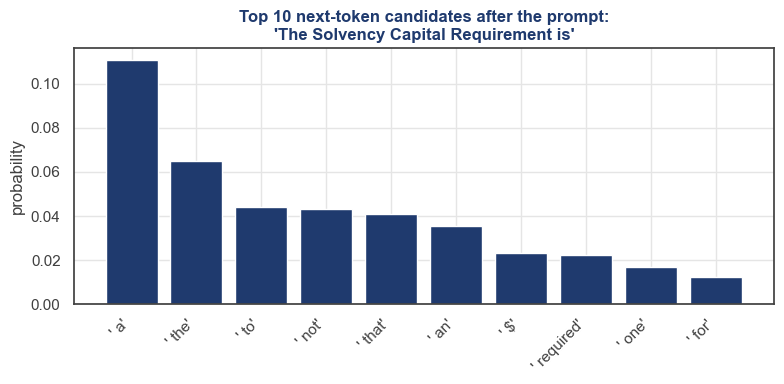

In [6]:
# Softmax turns the raw logits into a probability distribution over the whole vocab.
probs = torch.softmax(next_logits, dim=-1)

# Pull out the 10 most likely next tokens and their probabilities.
top_k = 10
top_probs, top_indices = torch.topk(probs, top_k)
top_tokens = [tokenizer.decode([idx]).replace("\n", "\\n") for idx in top_indices.tolist()]

# Bar chart of the top-k candidates.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(top_k), top_probs.numpy(), color=PRIMARY)
ax.set_xticks(range(top_k))
ax.set_xticklabels([repr(t) for t in top_tokens], rotation=45, ha="right")
ax.set_ylabel("probability")
ax.set_title(f"Top {top_k} next-token candidates after the prompt:\n{prompt!r}")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/02_top_k_next_token.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

That's the whole story of an LLM: a probability distribution over the next token, conditioned on whatever came before. To generate text, we sample one token, append it to the prompt, and run the whole thing through again. That's it.

But *how* you sample matters a lot — and that's where temperature and top-p come in.

### 2.3 Sampling Knobs — How Temperature and top-p Reshape the Same Distribution

The model gives us logits. Temperature scales them before softmax:

$$ p_i \propto \exp(\mathrm{logit}_i / T) $$

- **T < 1** sharpens the distribution: the most likely tokens get even more probability, the long tail collapses. Outputs become more deterministic and repetitive.
- **T = 1** uses the raw distribution from the model.
- **T > 1** flattens the distribution: more variety, but also more nonsense.

Let's see this on the *exact same* logits we just computed.

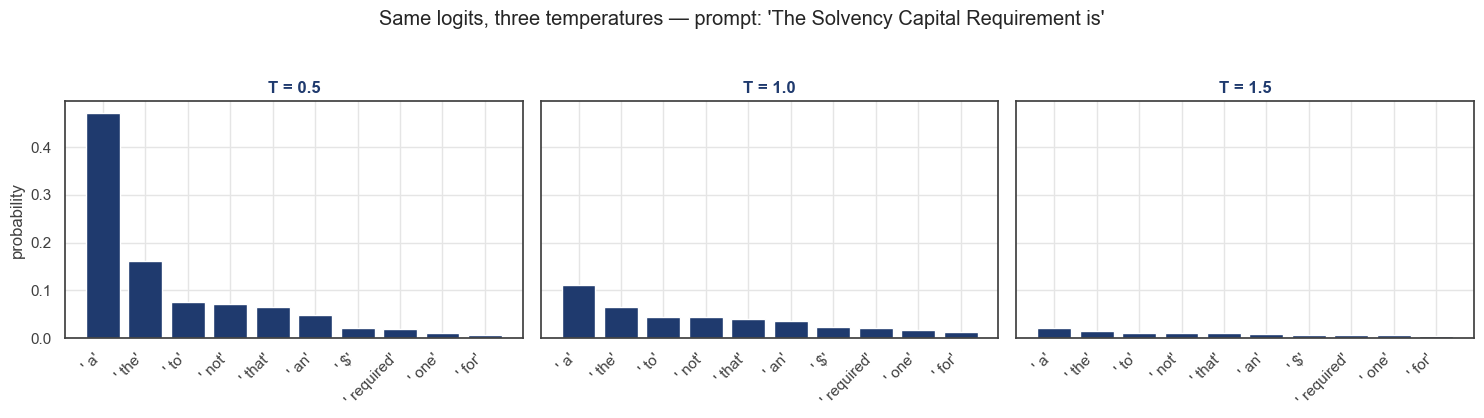

In [7]:
# Temperature rescales the logits BEFORE the softmax: softmax(logits / T).
def softmax_with_temperature(logits, T):
    return torch.softmax(logits / T, dim=-1)

# Compare three temperatures on the SAME logits we computed above.
temperatures = [0.5, 1.0, 1.5]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, T in zip(axes, temperatures):
    p = softmax_with_temperature(next_logits, T)
    top_p_vals, top_p_idx = torch.topk(p, top_k)  # re-rank under this temperature
    toks = [tokenizer.decode([idx]).replace("\n", "\\n") for idx in top_p_idx.tolist()]
    ax.bar(range(top_k), top_p_vals.numpy(), color=PRIMARY)
    ax.set_xticks(range(top_k))
    ax.set_xticklabels([repr(t) for t in toks], rotation=45, ha="right")
    ax.set_title(f"T = {T}")
    if T == temperatures[0]:
        ax.set_ylabel("probability")
fig.suptitle(f"Same logits, three temperatures — prompt: {prompt!r}", y=1.04)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/02_temperature_sweep.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

**top-p** (also called *nucleus sampling*) is a different lever. Instead of touching the temperature, it keeps the smallest set of tokens whose cumulative probability reaches *p* and zeroes out the rest — the model can never sample from outside that nucleus. GPT-2 is so unsure after this prompt that the probability is spread thin, so below we use a deliberately low `p` to keep the nucleus small enough to see clearly; production code typically uses `p` around 0.9.

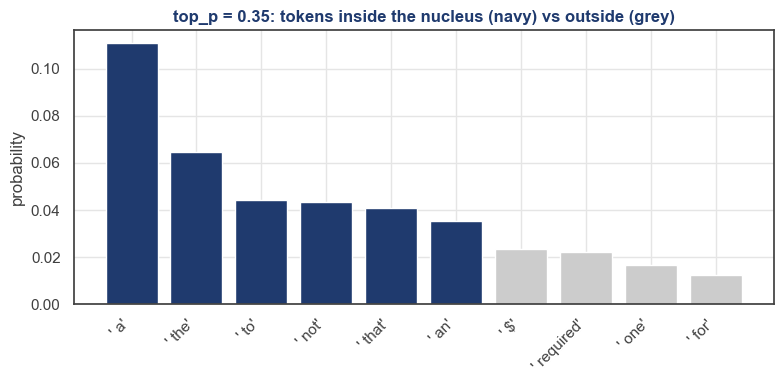

In [8]:
# Build a boolean "keep" mask for nucleus (top-p) sampling.
def top_p_mask(probs, p):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    # Keep tokens while the running cumulative probability stays below p...
    mask = cumulative < p
    mask[..., 0] = True  # ...and always keep the single most likely token.
    # Scatter the mask back into vocabulary order.
    keep = torch.zeros_like(probs, dtype=torch.bool)
    keep.scatter_(-1, sorted_idx, mask)
    return keep

# A deliberately small p so the nucleus is easy to see on this flat distribution:
# here it keeps just the top 6 tokens (production code typically uses ~0.9).
p_value = 0.35
nucleus_mask = top_p_mask(probs, p_value)
inside_nucleus = nucleus_mask[top_indices]  # which of the top-10 bars are inside?

# Colour the bars by membership: navy = inside the nucleus, grey = excluded.
fig, ax = plt.subplots(figsize=(8, 4))
colors = [PRIMARY if inside else "#CCCCCC" for inside in inside_nucleus.tolist()]
ax.bar(range(top_k), top_probs.numpy(), color=colors)
ax.set_xticks(range(top_k))
ax.set_xticklabels([repr(t) for t in top_tokens], rotation=45, ha="right")
ax.set_ylabel("probability")
ax.set_title(f"top_p = {p_value}: tokens inside the nucleus (navy) vs outside (grey)")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/02_top_p_nucleus.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

### 2.4 Greedy vs Sampled Generation

The simplest decoding rule is **greedy**: at each step, take the token with the highest probability. Deterministic, often repetitive, often boring.

Sampling means picking a token randomly according to the (temperature-modified, top-p-cropped) distribution. Less deterministic, more varied, sometimes weirder.

Let's generate two paragraphs from the same prompt, side by side.

In [9]:
prompt = "An actuary's main job is to"
# Encode the prompt AND build the attention mask, so generate() doesn't warn about it.
encoded = tokenizer(prompt, return_tensors="pt")
input_ids = encoded.input_ids
attention_mask = encoded.attention_mask

# GREEDY decoding: always take the single most likely next token (deterministic).
set_seed(SEED)
torch.manual_seed(SEED)
greedy_ids = model.generate(
    input_ids, attention_mask=attention_mask, max_new_tokens=40,
    do_sample=False, pad_token_id=tokenizer.eos_token_id,
)

# SAMPLED decoding: draw from the temperature/top-p-shaped distribution.
set_seed(SEED)
torch.manual_seed(SEED)
sampled_ids = model.generate(
    input_ids, attention_mask=attention_mask, max_new_tokens=40,
    do_sample=True, temperature=1.0, top_p=0.9,
    pad_token_id=tokenizer.eos_token_id,
)

print("GREEDY (do_sample=False):\n")
print(tokenizer.decode(greedy_ids[0], skip_special_tokens=True))
print("\n---\n")
print("SAMPLED (T=1.0, top_p=0.9):\n")
print(tokenizer.decode(sampled_ids[0], skip_special_tokens=True))

GREEDY (do_sample=False):

An actuary's main job is to make sure that the person is well-informed about the subject matter of the work.

The actuary's main job is to make sure that the person is well-informed about the subject matter

---

SAMPLED (T=1.0, top_p=0.9):

An actuary's main job is to record and analyze a deceased person's life. If someone is deceased, the funeral director would typically file it under a specific actuary's name.

The actuary's role includes conducting an analysis


> **Observation.** Pure greedy decoding often falls into loops ("the company the company the company..."). Sampling avoids the loop but can drift. In practice, frontier hosted models default to sampling with a moderate temperature (around 0.7–1.0) and let you push it lower for tasks that need consistency.

### 2.5 The Full Token-by-Token Loop, Made Visible

`model.generate(...)` hides the loop. Let's run it by hand, one token at a time, and print the result as it grows. This is exactly what happens under the hood every time you call any LLM.

In [10]:
prompt = "Reserving for IBNR claims requires"
input_ids = tokenizer.encode(prompt, return_tensors="pt")

set_seed(SEED)
torch.manual_seed(SEED)

# We grow `generated` one token at a time, starting from the prompt.
generated = input_ids
print(prompt, end="", flush=True)

with torch.no_grad():
    for step in range(30):
        # 1) Forward pass; take the logits for the next-token position.
        outputs = model(generated)
        next_logits = outputs.logits[0, -1, :]
        # 2) Convert logits to probabilities.
        probs_step = torch.softmax(next_logits, dim=-1)
        # 3) Apply top-p (nucleus) filtering with p = 0.9.
        sorted_probs, sorted_idx = torch.sort(probs_step, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=-1)
        mask = cumulative < 0.9
        mask[0] = True
        sorted_probs = sorted_probs.clone()
        sorted_probs[~mask] = 0
        sorted_probs = sorted_probs / sorted_probs.sum()  # renormalise the nucleus
        # 4) Sample one token from the surviving nucleus.
        choice = torch.multinomial(sorted_probs, num_samples=1)
        next_token = sorted_idx[choice]
        # 5) Append it, print it, and loop.
        generated = torch.cat([generated, next_token.unsqueeze(0)], dim=-1)
        print(tokenizer.decode(next_token), end="", flush=True)
print()

Reserving for IBNR claims requires a big goal: financing an all-new research facility within IBNR that has quantum means to explore alternative alternative strategies for its operations. Our interest


That visible loop is the *whole* model. Tokenise -> forward pass -> softmax -> sample -> append -> repeat. Frontier models do the same loop, just with a much bigger model and at much higher speed.

### 2.6 (Optional Aside) Token Embedding Geometry

Inside the model, every token ID is first looked up in an **embedding matrix** — a learned table that maps each of the ~50,000 token IDs to a vector (768 dimensions for GPT-2 small). The model learns to place semantically related tokens near each other in this space.

Let's pull out the embeddings for a handful of actuarial and non-actuarial words and project them to 2D with PCA.

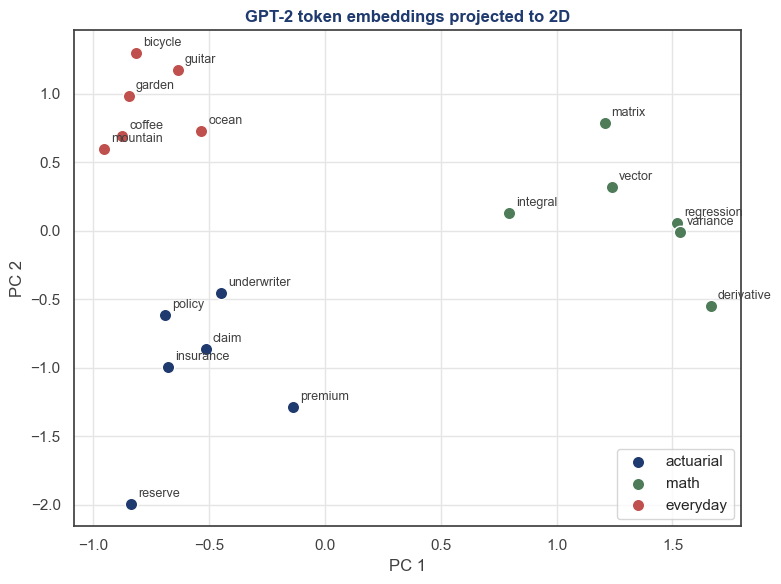

In [11]:
from sklearn.decomposition import PCA

# A handful of words from three domains: actuarial, mathematical, and everyday.
word_groups = {
    "actuarial": ["premium", "claim", "insurance", "reserve", "policy", "underwriter"],
    "math":      ["matrix", "vector", "integral", "derivative", "regression", "variance"],
    "everyday":  ["coffee", "guitar", "ocean", "mountain", "garden", "bicycle"],
}
group_colors = {"actuarial": PRIMARY, "math": ACCENT_GREEN, "everyday": ACCENT_RED}

# Look up each word's embedding vector (768-dim for GPT-2 small).
emb_vecs, labels, groups = [], [], []
for group, words in word_groups.items():
    for w in words:
        ids = tokenizer.encode(" " + w)  # leading space matches GPT-2's BPE convention
        # Use the embedding of the first sub-token; good enough for this viz.
        vec = model.transformer.wte(torch.tensor(ids[0])).detach().numpy()
        emb_vecs.append(vec)
        labels.append(w)
        groups.append(group)

# Project the 768-dim vectors down to 2D with PCA so we can plot them.
emb = np.array(emb_vecs)
proj = PCA(n_components=2, random_state=SEED).fit_transform(emb)

# Scatter, one colour per group, annotating each point with its word.
fig, ax = plt.subplots(figsize=(8, 6))
for group in word_groups:
    sel = [i for i, g in enumerate(groups) if g == group]
    ax.scatter(proj[sel, 0], proj[sel, 1], c=group_colors[group], label=group, s=80, edgecolor="white")
    for i in sel:
        ax.annotate(
            labels[i], (proj[i, 0], proj[i, 1]),
            xytext=(5, 5), textcoords="offset points", fontsize=9, color=GRAY_TEXT,
        )
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("GPT-2 token embeddings projected to 2D")
ax.legend()
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/02_embedding_pca.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

Even compressed from 768 dimensions down to 2, the three groups separate cleanly here. The first principal component (horizontal axis) pulls the mathematical vocabulary (`matrix`, `vector`, `derivative`, …) out to the right, while the second component (vertical axis) splits the actuarial terms (lower half) from the everyday words (upper half). Nobody labelled these categories for the model — this geometry is learned purely from how often words co-occur in the training text, and it is the space the rest of the model computes over.

### 2.7 (Optional Aside) One Attention Head, Visualized

The transformer reads a sequence with **attention**: at each position, a token decides how much to "look at" every *earlier* token before updating its own representation. GPT-2 small has 12 layers × 12 heads = 144 of these attention patterns, and they specialise — some track syntax, some track position, some do nothing interpretable at all.

Below we plot one of the cleanest, **layer 4, head 11**. Read the heatmap row by row: each row is one token (the *query*) and the colours show how much weight it puts on each earlier token (the *keys*). Two things to look for:

- The whole **upper-right triangle is empty**. GPT-2 is *causal* — a token can attend only to itself and the tokens before it, never to the future.
- This head puts almost all of its weight one step back: every token attends to the token *immediately before it*. "Previous-token heads" like this are a common, interpretable building block, and the model composes many such simple patterns into the behaviour you actually see.

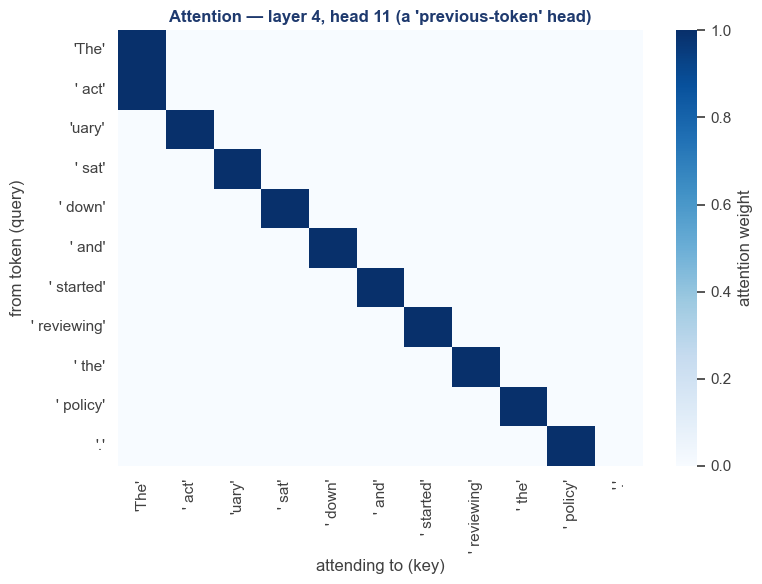

In [12]:
prompt = "The actuary sat down and started reviewing the policy."
input_ids = tokenizer.encode(prompt, return_tensors="pt")
input_tokens = [tokenizer.decode([tid]) for tid in input_ids[0].tolist()]

# Ask the model to also return its attention weights (works because we loaded the
# model with attn_implementation="eager" back in §2.2).
with torch.no_grad():
    outputs = model(input_ids, output_attentions=True)
    attentions = outputs.attentions             # tuple of length 12, one entry per layer
    layer, head = 4, 11                          # a clean "previous-token" head
    attn = attentions[layer][0, head].numpy()    # shape: (seq_len, seq_len)

# Heatmap: rows = the querying token, columns = the token being attended to.
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    attn,
    xticklabels=[repr(t) for t in input_tokens],
    yticklabels=[repr(t) for t in input_tokens],
    cmap="Blues", cbar_kws={"label": "attention weight"}, ax=ax,
)
ax.set_xlabel("attending to (key)")
ax.set_ylabel("from token (query)")
ax.set_title(f"Attention — layer {layer}, head {head} (a 'previous-token' head)")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/02_attention_heatmap.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

> **Warning.** Don't over-read a single head. We picked an unusually tidy one to make the mechanism tangible; most heads are far messier, and a separate phenomenon — "attention-sink" heads that dump most of their weight onto the very first token — is also common. No single head tells the whole story. The point here is only that attention is a concrete, inspectable weighting over earlier tokens, not magic.

### 2.8 Why This Matters — and Why We Now Move to Frontier Models

What you have just seen — tokenise, forward pass, next-token distribution, sample, append, repeat — is what every modern LLM does. GPT-5.5 and Claude Opus 4.8 are bigger (hundreds of billions to over a trillion parameters), trained on far more data (trillions of tokens), and trained for longer. They also add architectural refinements GPT-2 does not have — most notably **Mixture-of-Experts (MoE)** layers, where each token is routed through only a few of many specialised sub-networks, so the model can hold a trillion parameters but activate only a fraction of them per token. Other additions include longer-range attention variants and, increasingly, native multimodal encoders. But the *core loop* is exactly the one you just watched.

Two consequences:

- **What goes in shapes what comes out.** The training data, the system prompt, and the in-context examples all condition that same next-token distribution.
- **There is no symbolic reasoning under the hood.** When the model "computes" or "reasons", it is still just emitting tokens that are statistically likely given everything it saw during training. That is why prompt engineering works — and why even frontier models still hallucinate.

From here on, we use cloud-hosted frontier models via the OpenAI Responses API.

## 3. The Provider and Model Landscape

The LLM market in mid-2026 has a handful of serious players. The table below covers the models you are most likely to hit in an actuarial workflow, with current cheap-tier and frontier-tier options for each. **Every price and capability claim is dated** — the prices below are pulled from public pricing pages on **2026-05-26** and they move regularly.

| Provider | Model | Tier | Input / Output ($ per 1M tok) | Context | Modality | Tool use | Reasoning option | Notes |
|---|---|---|---|---|---|---|---|---|
| OpenAI | GPT-5.5 | Frontier | 5.00 / 30.00 | 200K+ | text + image | yes | yes | Newest general flagship (Apr 2026). |
| OpenAI | **GPT-5.4 Mini** | Cheap+fast | 0.75 / 4.50 | 200K+ | text + image | yes | optional | **Default model used in this notebook.** |
| OpenAI | GPT-5.4 Nano | Cheapest | 0.20 / 1.25 | 200K+ | text + image | yes | no | Ultra-light tier. |
| Anthropic | Claude Opus 4.8 | Frontier | 5.00 / 25.00 | 1M | text + image | yes | yes | Most capable Claude. |
| Anthropic | Claude Sonnet 4.6 | Balanced | 3.00 / 15.00 | 1M | text + image | yes | yes | Strong general workhorse. |
| Anthropic | Claude Haiku 4.5 | Cheap+fast | 1.00 / 5.00 | 200K | text + image | yes | no | Fastest Claude. |
| Google | Gemini 2.5 Pro | Frontier | 1.25 / 10.00 | 1M | text + image + audio + video | yes | yes | Frontier multimodal; input price rises above 200K context. |
| Google | Gemini 2.5 Flash | Cheap+fast | 0.30 / 2.50 | 1M | text + image + audio + video | yes | yes | Multimodal, very long context. |
| Mistral | Mistral Small 4 | Cheap, open weights | 0.15 / 0.60 | 256K | text + image | yes | yes | Apache 2.0; self-host or hosted. |
| Meta | Llama 4 Scout / Maverick | Open weights | self-hosted | 1M – 10M | text + image | via tooling | varies | Llama Community License. |

*Sources: provider pricing pages and model cards as of 2026-05-26. Prices and feature flags change frequently — always re-check before relying on them.*

A few observations:

- **The cheap tier is genuinely cheap.** A 500-token reply on a Mini-class model is roughly 0.4 cents.
- **Frontier vs cheap is about 5–10x** in dollars and meaningful in capability, but the cheap tier is good enough for most actuarial drafting, classification, and extraction work.
- **Context windows are large** — million-token context is now baseline for Sonnet, Opus, Gemini. Long policy documents fit easily.
- **Everyone supports vision input.** All current frontier and cheap-tier models accept images alongside text.
- **"Reasoning" is a runtime toggle.** Recent models can optionally spend extra compute "thinking" before answering. It costs more, but it helps on multi-step problems.

### How to pick a model

- **Start cheap.** Use the Mini / Haiku / Flash tier first. Upgrade only when you see the cheap tier failing on real examples.
- **Match modality.** If your input has images, pick a model that takes images natively. (All the listed models do, in 2026.)
- **Watch the context window.** Long policy contracts, long PDFs — pick a 1M-context model so you do not have to chunk.
- **Care about data residency?** EU-hosted endpoints exist for OpenAI (Azure OpenAI EU) and Anthropic via partner clouds; check before sending policyholder data.
- **Need offline?** Open-weights (Llama, Mistral, Qwen) self-host on your own GPUs.

Section 6 of the seminar shows where the *frontier* matters: structured outputs, function calling, and multi-step retrieval-augmented workflows benefit visibly from a more capable model.

## 4. Accessing LLMs via API

We use **OpenAI's Responses API** throughout, with `gpt-5.4-mini` as the default model. The Responses API is OpenAI's current flagship surface (it generalises and supersedes the older Chat Completions API). The same patterns translate directly to Anthropic's Messages API and Google's Gemini API; only the SDK calls differ.

### 4.1 Authentication with `.env`

We never hard-code API keys. Instead:

1. Copy `.env.example` (in this folder) to `.env`.
2. Paste your `OPENAI_API_KEY` into `.env`.
3. Restart this notebook so `python-dotenv` picks it up.

`.env` is gitignored (see the repo's `.gitignore`), so accidental commits do not leak keys.

> **Tip.** For production deployments, use your cloud's secret manager (AWS Secrets Manager, Azure Key Vault, GCP Secret Manager) instead of `.env`. `.env` is fine for laptop and notebook work.

In [13]:
MODEL_DEFAULT  = "gpt-5.4-mini"   # cheap + fast tier (our default), as of 2026-05-26
MODEL_FRONTIER = "gpt-5.5"        # frontier tier, for the one cautionary contrast below

# Instantiate the OpenAI client only if a key is present; otherwise skip cloud cells.
if HAS_OPENAI_KEY:
    from openai import OpenAI
    client = OpenAI()  # reads OPENAI_API_KEY from the environment
else:
    client = None
    print("No OPENAI_API_KEY found — every cloud cell below will skip with a printed message.")

### 4.2 First Cloud Call — OpenAI Responses API

The Responses API call is a one-liner.

In [14]:
prompt = "In one sentence, what is the Solvency Capital Requirement (SCR)?"

if HAS_OPENAI_KEY:
    # The Responses API: pass a model and an input string, get a response object back.
    response = client.responses.create(
        model=MODEL_DEFAULT,
        input=prompt,
    )
    print(response.output_text)  # .output_text is the convenience accessor for the reply
else:
    print("[skipped — no OPENAI_API_KEY] Example expected output:")
    print('"The Solvency Capital Requirement (SCR) is the amount of own funds an EU insurer ..."')

The Solvency Capital Requirement (SCR) is the amount of capital an insurer must hold to be able to withstand significant losses and remain solvent over a one-year period with a high level of confidence.


The response object carries more than just the text — model name, token counts, finish reason. Useful for logging and cost tracking.

In [15]:
if HAS_OPENAI_KEY:
    # The response object carries metadata useful for logging and cost tracking.
    print("model:", response.model)
    print("usage:", response.usage)          # input / output / total token counts
    print("output text length (chars):", len(response.output_text))
else:
    print("[skipped — no OPENAI_API_KEY]")

model: gpt-5.4-mini-2026-03-17
usage: ResponseUsage(input_tokens=21, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=44, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=65)
output text length (chars): 202


### 4.3 Local vs Cloud — Production Trade-offs

We just ran GPT-2 locally in Section 2 — but that was a *teaching* demo. For real workloads the trade-off table is what matters.

| Dimension | Cloud API (e.g. OpenAI / Anthropic) | Local / self-hosted (Ollama, vLLM, Llama 4) |
|---|---|---|
| **Latency** | 100 ms to a few seconds round-trip from the EU. | Depends entirely on your hardware; GPU can be faster, CPU much slower. |
| **Cost** | Per-token; predictable; no fixed cost. | Hardware + ops + electricity; predictable only at scale. |
| **Capability ceiling** | Frontier (200B+ parameter dense, MoE, reasoning). | Open-weights catch up but typically lag the frontier by 6–12 months on hard tasks. |
| **Data residency / GDPR** | Goes to a US (or EU) provider's servers; needs DPA, SCCs, etc. | Stays on your hardware, period. |
| **Confidentiality / IP** | Provider sees prompts; check terms re training on inputs. | You see prompts; nobody else does. |
| **Operations burden** | None — provider handles uptime, scaling, model updates. | High — you patch, scale, monitor, swap GPUs. |
| **Model availability** | Subject to provider's catalogue; deprecations happen. | You pick a checkpoint and pin it forever. |
| **Best fit** | Most workflows. Rapid iteration. Anything with sensible vendor risk. | Confidential / regulated data; on-prem requirements; very high volume where amortisation beats per-token pricing. |

Two production-grade local stacks worth knowing about:

- **Ollama** — the easiest way to run an open-weights model locally. One command pulls Llama 4 / Mistral Small 4 / Qwen 3.5 and exposes an **OpenAI-compatible** endpoint on `localhost:11434`. You can reuse the OpenAI Python SDK by pointing its `base_url` at that endpoint — `OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")` (the key is ignored locally, but the SDK still requires a non-empty string). One caveat: the local server speaks the older **Chat Completions** API (`client.chat.completions.create(...)`), not the newer Responses API we use here — the call shape is very similar, but it is not literally the same line of code.
- **vLLM** — a production-grade inference server for transformer models. Handles batching and KV-cache reuse properly, and likewise exposes an OpenAI-compatible Chat Completions endpoint. Used by many in-house deployments.

A typical actuarial example where local matters: customer-complaint classification on data containing names, claim numbers, and free-text descriptions that you do not want crossing a vendor boundary.

> **Note.** The "GPT-2 on a CPU" we ran in Section 2 is *not* a viable production local stack. Modern open-weights models are 100–1000x larger and need GPU(s) to be useful in real time.

### 4.4 A Tiny Multimodal Demo

All current frontier and cheap-tier models accept image inputs. Let's send one image to `gpt-5.4-mini` and ask for a caption.

To keep the notebook self-contained and reproducible, we generate a tiny synthetic "claim form" image at runtime — no downloads, no external assets.

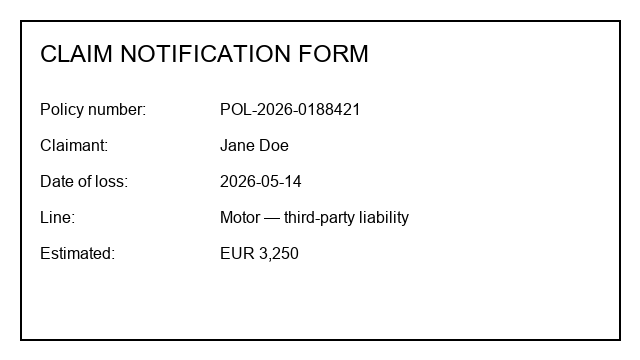

In [16]:
from PIL import Image, ImageDraw, ImageFont

# Build a tiny synthetic "claim form" image at runtime (no external downloads).
def make_claim_form_image(path):
    img = Image.new("RGB", (640, 360), "white")
    draw = ImageDraw.Draw(img)
    # Try a real TrueType font; fall back to PIL's built-in bitmap font if unavailable.
    try:
        font_title = ImageFont.truetype("arial.ttf", 24)
        font_body  = ImageFont.truetype("arial.ttf", 16)
    except Exception:
        font_title = ImageFont.load_default()
        font_body  = ImageFont.load_default()
    draw.rectangle((20, 20, 620, 340), outline="black", width=2)
    draw.text((40, 40), "CLAIM NOTIFICATION FORM", fill="black", font=font_title)
    # A handful of label / value rows.
    lines = [
        ("Policy number:", "POL-2026-0188421"),
        ("Claimant:",      "Jane Doe"),
        ("Date of loss:",  "2026-05-14"),
        ("Line:",          "Motor — third-party liability"),
        ("Estimated:",     "EUR 3,250"),
    ]
    y = 100
    for label, value in lines:
        draw.text((40, y), label, fill="black", font=font_body)
        draw.text((220, y), value, fill="black", font=font_body)
        y += 36
    img.save(path)
    return path

claim_form_path = f"{FIG_DIR}/sample_claim_form.png"
make_claim_form_image(claim_form_path)
Image.open(claim_form_path)  # display it inline

We send this image to the model as a base64-encoded data URL and ask for a one-sentence caption. The Responses API takes a structured `input` list when you mix text and images.

In [17]:
# Read an image file and return its base64-encoded bytes (for the data URL below).
def encode_image_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

if HAS_OPENAI_KEY:
    b64 = encode_image_b64(claim_form_path)
    # Mixed text + image input: the Responses API takes a structured content list.
    response = client.responses.create(
        model=MODEL_DEFAULT,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": "Describe this document in one sentence."},
                    {"type": "input_image", "image_url": f"data:image/png;base64,{b64}"},
                ],
            }
        ],
    )
    print(response.output_text)
else:
    print("[skipped — no OPENAI_API_KEY] Example expected output:")
    print("'A simple insurance claim notification form showing policy POL-2026-0188421 ...'")

This document is a claim notification form summarizing an insurance claim for policy POL-2026-0188421 filed by Jane Doe for a motor third-party liability loss dated 2026-05-14 with an estimated amount of EUR 3,250.


## 5. API Parameters and How They Shape Output

Two parameters move the needle the most for everyday actuarial workloads:

- `instructions` — the system-prompt equivalent. Carries the persistent task framing.
- `temperature` — randomness knob (default around 0.7 in the Responses API; set to 0 for the closest thing to deterministic output).

Plus an important caveat: the Responses API has **no `seed` parameter** (unlike the legacy Chat Completions API). The closest thing to reproducibility on the Responses API is `temperature=0` — and even that is best-effort. See [§5.3](#53-reproducibility-and-the-limits-of-api-determinism).

Two parameters worth knowing about but not demoed here:

- `max_output_tokens` — caps the response length. Use for cost and latency control.
- `top_p` — alternative randomness knob; rarely needed once you have fixed `temperature`.

### 5.1 The `instructions` Parameter — System-Prompt Swap

Same user prompt, two different `instructions`. The first is a generic explainer; the second is a senior-actuary persona aimed at a board-level audience.

In [18]:
user_prompt = "Explain why mortality experience can deviate from a best-estimate assumption."
# Two different system prompts (instructions), same user question.
instr_plain   = "You are a helpful assistant."
instr_actuary = (
    "You are a senior life actuary. Answer in three short paragraphs aimed at a board-level audience: "
    "define the issue, give two concrete drivers of deviation, and end with a one-sentence practical takeaway."
)

if HAS_OPENAI_KEY:
    # Same input, swapped instructions -> very different style, length, and framing.
    r1 = client.responses.create(model=MODEL_DEFAULT, input=user_prompt, instructions=instr_plain)
    r2 = client.responses.create(model=MODEL_DEFAULT, input=user_prompt, instructions=instr_actuary)
    print("=== PLAIN instructions ===\n")
    print(r1.output_text)
    print("\n=== SENIOR-ACTUARY instructions ===\n")
    print(r2.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

=== PLAIN instructions ===

Mortality experience can deviate from a best-estimate assumption because the best estimate is only an average expectation, while actual outcomes are affected by randomness and changes in real-world conditions.

Main reasons include:

- **Random variation:** Even if assumptions are accurate on average, actual deaths in a portfolio can be higher or lower in a given period just by chance.
- **Selection effects:** The insured population may not behave exactly like the population used to set the assumption. For example, healthier people may be more likely to buy certain products.
- **Changes in underwriting or business mix:** New policyholders may have different risk profiles from earlier ones.
- **Environmental and social factors:** Pandemics, medical advances, lifestyle changes, economic conditions, or wars can affect mortality rates.
- **Age, gender, and cohort differences:** Mortality improvements may differ by generation or demographic group.
- **Policyholde

The `instructions` parameter is the single biggest lever for shaping output. Use it for role, audience, format, length, and tone — *not* for the specific question, which goes in `input`.

> **Forward pointer.** In Section 6, Structured Outputs extend the `instructions` pattern with a Pydantic-typed return schema, so the model is *guaranteed* to return parseable JSON.

### 5.2 Temperature — 0 vs 1

`temperature` controls randomness. For a task with a single right answer (classification, extraction) set `temperature=0`. For drafting or brainstorming, raise it. The effect is clearest on a *generative* task, so below we draft the same short customer message several times at each setting and compare.

In [19]:
# A generative task (drafting) shows temperature's effect far more clearly than a
# classification task, where the single correct label barely changes.
N_RUNS = 4
draft_prompt = (
    "Write a one-sentence apology to a policyholder whose contents-claim settlement "
    "has been delayed by six weeks. Professional and concise; no greeting or sign-off."
)

if HAS_OPENAI_KEY:
    # temperature = 0 -> greedy decoding -> the runs should be identical.
    print(f"=== temperature = 0 ({N_RUNS} runs) ===")
    for _ in range(N_RUNS):
        r = client.responses.create(model=MODEL_DEFAULT, input=draft_prompt, temperature=0.0)
        print("  ->", r.output_text.strip())
    # temperature = 1 -> sampling -> same meaning, different wording each run.
    print(f"\n=== temperature = 1.0 ({N_RUNS} runs) ===")
    for _ in range(N_RUNS):
        r = client.responses.create(model=MODEL_DEFAULT, input=draft_prompt, temperature=1.0)
        print("  ->", r.output_text.strip())
else:
    print("[skipped — no OPENAI_API_KEY]")

=== temperature = 0 (4 runs) ===
  -> We sincerely apologize for the six-week delay in settling your contents claim and understand the inconvenience this has caused.
  -> We sincerely apologize for the six-week delay in settling your contents claim and understand the inconvenience this has caused.
  -> We sincerely apologize for the six-week delay in settling your contents claim and understand the inconvenience this has caused.
  -> We sincerely apologize for the six-week delay in settling your contents claim and understand the inconvenience this has caused.

=== temperature = 1.0 (4 runs) ===
  -> I’m sorry for the six-week delay in processing your contents claim settlement, and I appreciate your patience while we work to resolve it as quickly as possible.
  -> We sincerely apologize for the six-week delay in settling your contents claim and understand the frustration this has caused.
  -> We sincerely apologize for the six-week delay in settling your contents claim and understand the

At `temperature=0`, greedy decoding takes the single most-likely token at every step, so the `N_RUNS` drafts come back **identical** (or all but identical). At `temperature=1`, the sampler injects randomness: the drafts carry the **same meaning but different wording** run to run. That is the whole trade-off — `temperature=0` for reproducible classification and extraction, a higher temperature when you want drafting variety. (On an easy single-label task like the complaint sorter in [§6.2](#62-few-shot--give-the-model-the-pattern), even `temperature=1` barely moves: there is little for the randomness to change.)

### 5.3 Reproducibility and the Limits of API Determinism

The Responses API does **not** expose a `seed` parameter — that one lives on the older Chat Completions API only. The closest you get to deterministic output on the Responses API is `temperature=0`, which switches the sampler to **greedy decoding**: at each step pick the single highest-probability token. The same prompt + same model + `temperature=0` will *usually* give the same response across two consecutive runs.

Let's confirm that on a short actuarial prompt: same call, twice.

In [20]:
if HAS_OPENAI_KEY:
    # Call the exact same prompt twice at temperature=0 and compare the two replies.
    outs = []
    for _ in range(2):
        r = client.responses.create(
            model=MODEL_DEFAULT,
            input="Give me one short sentence on operational risk under Solvency II.",
            temperature=0.0,
        )
        outs.append(r.output_text.strip())
    print("Run 1:", outs[0])
    print("Run 2:", outs[1])
    print("Identical across runs:", outs[0] == outs[1])
else:
    print("[skipped — no OPENAI_API_KEY]")

Run 1: Operational risk under Solvency II is the risk of loss arising from inadequate or failed internal processes, people, systems, or external events.
Run 2: Operational risk under Solvency II is the risk of loss arising from inadequate or failed internal processes, people, systems, or external events.
Identical across runs: True


> **Warning.** Even with `temperature=0`, identical output across runs is **not** a compliance guarantee. Provider-side model updates, regional routing, and batching can change outputs from one day to the next without notice. If you need reproducibility for a regulator-facing process, **log the exact prompt, the exact model ID, and the exact response text** — and rely on those logs rather than expecting future calls to reproduce.
>
> If you specifically need a `seed` parameter (e.g. to match older code or to debug a controlled experiment across runs), the legacy Chat Completions API (`client.chat.completions.create`) still exposes one. The Responses API does not. For nearly all actuarial use cases `temperature=0` + thorough logging is what you actually want.

## 6. Prompt Engineering Techniques

There is no shortage of "prompting tricks" floating around. The ones below are the ones with the most reliable empirical support and the most direct actuarial use. We demo five in code and mention two more.

### 6.1 Zero-Shot

"Zero-shot" just means: ask the question, give no examples. Modern frontier models are remarkably good at zero-shot on common tasks.

In [21]:
# Zero-shot: just ask the question, with no worked examples.
zs_prompt = "Explain the Solvency Capital Requirement (SCR) to a non-actuarial executive in three sentences."

if HAS_OPENAI_KEY:
    r = client.responses.create(model=MODEL_DEFAULT, input=zs_prompt)
    print(r.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

The Solvency Capital Requirement (SCR) is the amount of capital an insurer needs to hold so it can absorb severe but plausible losses over the next year and still meet its obligations to policyholders.  
It is designed as a regulatory safety buffer, based on a standardized or internal risk model that considers risks like market movements, underwriting losses, credit defaults, and operational events.  
In simple terms, the SCR tells management and regulators how financially resilient the company is under stress, and whether it has enough capital to remain solvent.


### 6.2 Few-Shot — Give the Model the Pattern

When zero-shot is fuzzy on format or style, show a few examples. "Few-shot" usually means 1–5 examples that match the task.

We use this on complaint classification: same task as before, but with three labeled examples in the prompt.

In [22]:
# Few-shot: three labelled examples teach the model the exact task and output format.
fs_prompt = """Classify each customer complaint into exactly one of:
SERVICE, CLAIMS-HANDLING, PRICING, OTHER. Return only the label.

Examples:
Complaint: "My agent never returns my calls."  ->  SERVICE
Complaint: "You doubled my premium with no warning."  ->  PRICING
Complaint: "Six weeks and no decision on my motor claim."  ->  CLAIMS-HANDLING

Now classify:
Complaint: "I've been on hold for forty minutes trying to reach a human."
"""

if HAS_OPENAI_KEY:
    r = client.responses.create(model=MODEL_DEFAULT, input=fs_prompt, temperature=0.0)
    print(r.output_text.strip())
else:
    print("[skipped — no OPENAI_API_KEY] Expected: SERVICE")

SERVICE


### 6.3 Chain-of-Thought — "Let's Think Step by Step"

On tasks that involve multiple steps of reasoning (arithmetic, multi-clause logic, multi-step extraction), explicitly asking the model to lay out its reasoning before the answer often improves accuracy. The classic phrasing is *"Let's think step by step"* (Kojima et al., 2022).

In [23]:
# Chain-of-thought: explicitly ask the model to reason step by step before answering.
cot_prompt = """A 45-year-old non-smoker buys a 20-year level term life insurance policy with a sum assured of EUR 200,000
and a level premium of EUR 320 per year. The insurer's annual expense loading is 12% of the gross premium.
The risk-free rate is 3% per year and the insurer assumes a constant probability of death of 0.0015 per year.

Estimate the insurer's expected profit per policy at issue, ignoring lapses.
Show your reasoning step by step before giving the final number.
"""

if HAS_OPENAI_KEY:
    r = client.responses.create(model=MODEL_DEFAULT, input=cot_prompt, temperature=0.0)
    print(r.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

Let’s estimate the insurer’s **expected profit at issue** as:

\[
\text{Expected Profit} = \text{PV of premiums} - \text{PV of expected claims} - \text{PV of expenses}
\]

We’ll use the given assumptions:

- Policy term: **20 years**
- Sum assured: **EUR 200,000**
- Annual premium: **EUR 320**
- Expense loading: **12% of gross premium**
- Risk-free rate: **3%**
- Annual probability of death: **0.0015**
- Ignore lapses

---

## 1) Present value of premiums

Premiums are paid annually for 20 years, assuming the policyholder survives to each payment date.

Let:

- \( v = \frac{1}{1.03} \)
- \( q = 0.0015 \)
- \( p = 1-q = 0.9985 \)

The expected PV of premiums is:

\[
320 \sum_{t=1}^{20} v^t p^{t-1}
\]

This is a geometric series:

\[
320 \cdot v \sum_{t=0}^{19} (vp)^t
\]

Compute:

\[
v = 0.9708738,\quad vp = 0.9708738 \times 0.9985 \approx 0.9694176
\]

So:

\[
\sum_{t=0}^{19} (vp)^t = \frac{1-(vp)^{20}}{1-vp}
\]

\[
(vp)^{20} \approx 0.538
\]

\[
\frac{1-0.538}{1-0.9694176} \approx \fr

> **Warning.** Chain-of-thought helps on reasoning tasks but is no guarantee of correctness. LLMs can produce *plausible-sounding* reasoning that arrives at a wrong number. Always sanity-check the arithmetic. This is one of the reasons Section 6 of the seminar covers **Function Calling** — for arithmetic you trust, route to Python, not to the model.

### 6.4 Role / System Prompts and Delimiters

Two patterns to always combine:

1. Set a clear role in `instructions` — "You are a senior life actuary explaining to a board-level audience."
2. Use explicit delimiters around the user-supplied content — triple backticks, XML tags, or `===` work fine. Delimiters help the model distinguish *instructions* from *data*, and they make basic prompt-injection harder.

In [24]:
# Set the role in `instructions`; fence the user-supplied data in triple backticks.
role_instructions = (
    "You are a P&C actuary. Read the customer complaint between the triple backticks "
    "and return ONLY a one-word category from {SERVICE, CLAIMS-HANDLING, PRICING, OTHER}."
)

user_input = """```
Hi — my home insurance auto-renewed at a premium 35% higher than last year, no email warning, no explanation. I want this rolled back.
```"""

if HAS_OPENAI_KEY:
    r = client.responses.create(
        model=MODEL_DEFAULT,
        input=user_input,
        instructions=role_instructions,
        temperature=0.0,
    )
    print(r.output_text.strip())
else:
    print("[skipped — no OPENAI_API_KEY] Expected: PRICING")

PRICING


### 6.5 Output-Format Hints

Ask for the format you need. The model will usually comply — *usually*. For workflows where you cannot tolerate format drift, Section 6 of the seminar shows the guaranteed approach (Structured Outputs).

In [25]:
# Output-format hint: ask for a specific structure (here, a markdown table).
fmt_prompt = """Extract the policy number and the estimated claim amount from the text below.
Return ONLY a markdown table with columns "field" and "value", no prose.

Text:
```
On 2026-05-14, claimant Jane Doe (policy POL-2026-0188421) notified a motor third-party claim. Initial reserve set at EUR 3,250.
```
"""

if HAS_OPENAI_KEY:
    r = client.responses.create(model=MODEL_DEFAULT, input=fmt_prompt, temperature=0.0)
    print(r.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

| field | value |
|---|---|
| policy number | POL-2026-0188421 |
| estimated claim amount | EUR 3,250 |


> **Forward pointer.** Output-format hints are best-effort. Section 6 shows the guarantee — **Structured Outputs**, where the model is constrained to return a Pydantic-typed JSON object that always parses.

### 6.6 Mentioned, Not Demoed — Self-Consistency and Prompt Chaining

Two techniques worth knowing about, in case you hit a hard problem the simpler patterns do not solve:

- **Self-consistency.** Sample several chain-of-thought answers at non-zero temperature, and majority-vote. Often improves accuracy on math-heavy questions — at the cost of *n*x tokens.
- **Prompt chaining.** Break a hard task into a sequence of calls — *extract*, then *normalise*, then *classify*. The intermediate outputs are easier to debug than a single monolithic prompt.

Both are well-documented in the prompting literature. We do not demo them here because (a) self-consistency is expensive, and (b) prompt chaining is essentially what the Section 6 RAG pipeline does in a more structured form.

## 7. Honest Framing — What LLMs Get Wrong

A clear-eyed view of what cannot be wished away with better prompts.

- **Hallucination.** The model emits a plausible-sounding statement that is factually wrong. Common on rare facts, specific numbers, names, citations.
- **Training-cutoff staleness.** The model only knows about events up to its training data. Live data — yesterday's market, today's policy database — is invisible to it.
- **Prompt sensitivity.** Small changes in wording can change outputs. Determinism is best-effort, not guaranteed (see [§5.3](#53-reproducibility-and-the-limits-of-api-determinism)).
- **Prompt injection / jailbreaks.** User-supplied content can override your `instructions`. Always treat data as data — quote it, delimit it, never blend it with instructions.
- **Confidentiality.** Cloud APIs see your prompts. Check the provider's terms (training on inputs, retention period, regional routing). For sensitive policyholder data, prefer local hosting or EU-resident endpoints with proper DPAs.
- **Evaluation is hard.** Unlike a regression model with RMSE, you cannot just "score" an LLM output. Evaluation needs human spot-checks, golden-set comparisons, or judge-LLMs (see [§9](#9-how-do-you-even-test-this-thing--evaluation-sketch)).

Each limitation has a partial answer in the next section of the seminar:

| Section 5 limitation | Section 6 building block that resolves it | Concrete actuarial example in Section 6 |
|---|---|---|
| "Output format is fragile" | **Structured Outputs** | Car-insurance policy field extraction (RISCBAC corpus) |
| "Can't query our databases or run our own code" | **Function / Tool Calling** | Mortality-table SQLite lookup |
| "Hallucinates on domain-specific terminology" | **Fine-Tuning** | Car-damage image classification (6 classes) |
| "Knowledge cutoff — can't see internal docs or yesterday's data" | **Retrieval-Augmented Generation (RAG)** | KPI extraction from an insurer's annual report |

The four building blocks combine, in production, into end-to-end workflows that look much less mistake-prone than a single prompt to a single model. We see them one at a time in Section 6.

## 8. Concrete Token Cost — A Quick Estimator

Actuaries care about unit economics. Here is a back-of-envelope estimator for a single API call. We count the input tokens **exactly** with [`tiktoken`](https://github.com/openai/tiktoken) (the tokenizer OpenAI's API models use, which we met in [§2.1](#21-tokenization--words-to-tokens-to-ids)); the output side we cannot know until the model replies, so we assume a typical response length.

In [26]:
import tiktoken

# Per-model prices in USD per 1,000,000 tokens, as of 2026-05-26.
PRICING = {
    "gpt-5.4-mini":      (0.75,  4.50),
    "gpt-5.4-nano":      (0.20,  1.25),
    "gpt-5.5":           (5.00, 30.00),
    "claude-haiku-4-5":  (1.00,  5.00),
    "claude-sonnet-4-6": (3.00, 15.00),
    "claude-opus-4-8":   (5.00, 25.00),
    "gemini-2-5-flash":  (0.30,  2.50),
}

# o200k_base is the tokenizer used by current OpenAI API models.
enc = tiktoken.get_encoding("o200k_base")

def estimate_cost_usd(n_in, n_out, model="gpt-5.4-mini"):
    """Cost of one call given input and output token counts."""
    in_price, out_price = PRICING[model]
    return (n_in * in_price + n_out * out_price) / 1_000_000

# Use a real prompt from this notebook: the senior-actuary explainer from §5.1.
example_instructions = (
    "You are a senior life actuary. Answer in three short paragraphs aimed at a board-level audience: "
    "define the issue, give two concrete drivers of deviation, and end with a one-sentence practical takeaway."
)
example_input = "Explain why mortality experience can deviate from a best-estimate assumption."

# Count the input exactly; the reply is unknown offline, so assume a typical
# three-paragraph answer of ~220 tokens.
n_in  = len(enc.encode(example_instructions)) + len(enc.encode(example_input))
n_out = 220

print(f"Input tokens (instructions + prompt): {n_in}")
print(f"Assumed output tokens               : {n_out}\n")
print(f"{'model':20s}  cost per call (cents)")
print("-" * 45)
for m in PRICING:
    cents = estimate_cost_usd(n_in, n_out, model=m) * 100
    print(f"  {m:20s}  ~ {cents:7.4f}")

Input tokens (instructions + prompt): 55
Assumed output tokens               : 220

model                 cost per call (cents)
---------------------------------------------
  gpt-5.4-mini          ~  0.1031
  gpt-5.4-nano          ~  0.0286
  gpt-5.5               ~  0.6875
  claude-haiku-4-5      ~  0.1155
  claude-sonnet-4-6     ~  0.3465
  claude-opus-4-8       ~  0.5775
  gemini-2-5-flash      ~  0.0566


> **Forward pointer.** Section 6 shows **Function Calling**, which can offload deterministic actuarial computations (mortality lookups, premium tables, capital aggregation) to your own Python code. You pay for the LLM round trip; the computation itself runs locally and exactly.

## 9. How Do You Even Test This Thing? — Evaluation Sketch

Conventional software testing assumes deterministic outputs. LLMs are not deterministic. So how do you "test" a prompt?

Three pragmatic patterns:

1. **Spot-checks.** A small, hand-curated set of representative inputs that you eyeball after every change. Quick, qualitative.
2. **Golden-set comparison.** Pin a set of (input, expected-output) pairs and check that new outputs are "close enough" to expected on each. "Close enough" needs definition — exact match, fuzzy string, ROUGE, or judge-LLM.
3. **Judge-LLM.** Use a second LLM call to score your first LLM's output against a rubric. Cheap, scalable, biased — works well for ordering things ("which of these two responses is better?"), less well for absolute scoring.

We sketch the simplest version below — a tiny golden-set with exact-match scoring for the complaint-classification task.

In [27]:
# A tiny golden set: (complaint, expected label) pairs we can score against.
golden_set = [
    ("My agent never returns my calls.",                                   "SERVICE"),
    ("Six weeks and no decision on my motor claim.",                       "CLAIMS-HANDLING"),
    ("You doubled my premium with no warning.",                            "PRICING"),
    ("Is your office open on bank holidays?",                              "OTHER"),
    ("The adjuster lowballed my contents claim by 40%.",                   "CLAIMS-HANDLING"),
]

# Classify one complaint at temperature=0 (deterministic); return None if no key.
def classify(complaint):
    if not HAS_OPENAI_KEY:
        return None
    p = (
        "Classify into one of SERVICE, CLAIMS-HANDLING, PRICING, OTHER. Return only the label.\n"
        f"Complaint:\n```\n{complaint}\n```"
    )
    r = client.responses.create(model=MODEL_DEFAULT, input=p, temperature=0.0)
    return r.output_text.strip()

if HAS_OPENAI_KEY:
    # Score every golden example and tabulate predicted vs expected.
    rows = []
    for text, expected in golden_set:
        pred = classify(text)
        rows.append({
            "complaint": (text[:50] + "…") if len(text) > 50 else text,
            "expected": expected,
            "predicted": pred,
            "match": pred == expected,
        })
    df_eval = pd.DataFrame(rows)
    print(df_eval.to_string(index=False))
    print(f"\nAccuracy: {df_eval['match'].mean():.0%}")
else:
    print("[skipped — no OPENAI_API_KEY] Run locally with your key to score the golden set.")

                                       complaint        expected       predicted  match
                My agent never returns my calls.         SERVICE         SERVICE   True
    Six weeks and no decision on my motor claim. CLAIMS-HANDLING CLAIMS-HANDLING   True
         You doubled my premium with no warning.         PRICING         PRICING   True
           Is your office open on bank holidays?           OTHER         SERVICE  False
The adjuster lowballed my contents claim by 40%. CLAIMS-HANDLING CLAIMS-HANDLING   True

Accuracy: 80%


A real evaluation harness adds: many more examples, stratified by complaint sub-category; multiple runs per example to catch non-determinism; a baseline (random or majority class) to compare against; and a release process that re-runs the harness before every prompt change.

> **Tip.** Treat a prompt change like a code change. Version it, regression-test it, ship it through review. "I tweaked the prompt and it seemed to work" is not a release process.

## Exercises

Three short exercises, each grounded in a typical actuarial task. The solutions are inlined below each exercise — peek if you must, but try first.

### Exercise 1 — Three Ways to Explain the SCR

Take the user prompt "Explain the Solvency Capital Requirement to a non-actuarial executive." Send it to `gpt-5.4-mini` three ways:

1. **Zero-shot**, no `instructions`, default parameters.
2. **Few-shot**: prepend two short worked examples of "explain X in three sentences to a non-actuarial executive" (you choose X).
3. **Chain-of-thought**: prepend "Before answering, list the three points you want to make, then answer." with `temperature=0.0`.

Print all three outputs and write one sentence of comparison.

In [28]:
# Solution
# Build the prompt three different ways for the same underlying question.

def explain_scr(mode):
    base = "Explain the Solvency Capital Requirement to a non-actuarial executive."
    if mode == "zero-shot":
        prompt = base
        instr, temp = None, 0.7
    elif mode == "few-shot":
        prompt = (
            "Examples:\n\n"
            "Q: Explain a stop-loss reinsurance contract to a non-actuarial executive.\n"
            "A: A stop-loss treaty pays out once total annual losses exceed a fixed threshold. "
            "It caps the insurer's aggregate exposure. It is bought by insurers worried about an unusually bad year.\n\n"
            "Q: Explain reserve discounting to a non-actuarial executive.\n"
            "A: Reserves are estimates of future claim payouts. Discounting them means showing their value today, "
            "given that money paid in 5 years is worth less than money paid tomorrow. "
            "It makes the balance sheet more comparable across time.\n\n"
            "Q: " + base + "\nA:"
        )
        instr, temp = None, 0.7
    elif mode == "chain-of-thought":
        prompt = "Before answering, list the three points you want to make, then answer the question.\n\n" + base
        instr, temp = None, 0.0
    else:
        raise ValueError(mode)

    if HAS_OPENAI_KEY:
        kwargs = dict(model=MODEL_DEFAULT, input=prompt, temperature=temp)
        if instr is not None:
            kwargs["instructions"] = instr
        r = client.responses.create(**kwargs)
        return r.output_text
    return "[skipped — no OPENAI_API_KEY]"

for mode in ["zero-shot", "few-shot", "chain-of-thought"]:
    print(f"=== {mode} ===\n")
    print(explain_scr(mode))
    print("\n")

=== zero-shot ===

The **Solvency Capital Requirement (SCR)** is the amount of capital an insurer must hold to be considered financially resilient under a severe but plausible stress scenario.

### In plain English
Think of the SCR as the insurer’s **financial shock absorber**. It is designed to ensure the company can survive major losses over the next year and still pay policyholders.

### What it answers
It answers the question:

> “How much money should we have available so that, even if a bad year happens, we’re still very likely to meet our obligations?”

### What it covers
The SCR reflects risks such as:
- investment market downturns
- large insurance claims
- interest rate changes
- credit defaults
- operational failures
- catastrophe events

### How it’s used
Regulators use the SCR to judge whether an insurer is:
- **well-capitalized**
- able to **absorb unexpected losses**
- safe for policyholders

If an insurer’s available capital falls below the SCR, it usually triggers regu

### Exercise 2 — Classify Complaints with Output-Format Hints

Take the following five complaints. Build a single prompt that classifies them all in one call and returns a markdown table with columns `complaint_id`, `category` (SERVICE / CLAIMS-HANDLING / PRICING / OTHER), and `urgency` (LOW / MEDIUM / HIGH). Use `temperature=0`.

1. "I've been calling for three days. Voicemails go nowhere."
2. "Renewal premium is up 40% with no change in cover. Explain."
3. "My fire claim has been open since January. I need this resolved."
4. "What does 'aggregate excess' mean in my policy?"
5. "I want to add my partner as a named driver." 

In [29]:
# Solution
# One prompt classifies all five complaints in a single call and returns a table.

complaints = [
    "I've been calling for three days. Voicemails go nowhere.",
    "Renewal premium is up 40% with no change in cover. Explain.",
    "My fire claim has been open since January. I need this resolved.",
    "What does 'aggregate excess' mean in my policy?",
    "I want to add my partner as a named driver.",
]

# Number the complaints so the model can refer to them by id.
numbered = "\n".join(f"{i+1}. {c}" for i, c in enumerate(complaints))
prompt = f"""Classify the complaints below.

For each complaint return:
- `complaint_id` (1..5)
- `category` (one of SERVICE, CLAIMS-HANDLING, PRICING, OTHER)
- `urgency` (one of LOW, MEDIUM, HIGH)

Return ONLY a markdown table with those three columns.

Complaints:
```
{numbered}
```
"""

if HAS_OPENAI_KEY:
    r = client.responses.create(model=MODEL_DEFAULT, input=prompt, temperature=0.0)
    print(r.output_text)
else:
    print("[skipped — no OPENAI_API_KEY]")

| complaint_id | category | urgency |
|---|---|---|
| 1 | SERVICE | HIGH |
| 2 | PRICING | MEDIUM |
| 3 | CLAIMS-HANDLING | HIGH |
| 4 | OTHER | LOW |
| 5 | OTHER | LOW |


### Exercise 3 — Extract One or Two Fields from a Policy Schedule

You are given the short policy-schedule snippet below. Write a prompt that:

1. Extracts the **policy number** and the **annual gross premium** (in euros).
2. Returns the two values as `policy_number: ...` and `annual_premium_eur: ...` on two separate lines.

Use `temperature=0`. Then write a small parser that pulls the two values out of the model's output and stores them in a Python dict.

```text
Policy schedule:
Policy no.: POL-EU-2026-77913 | Inception: 01-01-2026 | Term: 12 months
Insured: Müller GmbH, Munich
Coverage: General liability, EUR 5,000,000 limit
Premium: gross EUR 18,420.00 (incl. 19% IPT), payable annually
Broker: Marsh Germany
```

> **Forward pointer.** You will hit the limits of plain prompting fast — currency symbols drift, "annual premium" vs "gross premium" gets ambiguous, optional fields confuse the model. In Section 6, **Structured Outputs** return to exactly this task on a larger schema (the open RISCBAC car-insurance corpus) and show how a Pydantic-typed return value eliminates all of the variability you are about to see.

In [30]:
# Solution

import re

snippet = """Policy schedule:
Policy no.: POL-EU-2026-77913 | Inception: 01-01-2026 | Term: 12 months
Insured: Müller GmbH, Munich
Coverage: General liability, EUR 5,000,000 limit
Premium: gross EUR 18,420.00 (incl. 19% IPT), payable annually
Broker: Marsh Germany"""

# Ask for exactly two fields in a fixed two-line format, so we can parse them back.
prompt = f"""Extract from the policy schedule below:
- the policy number
- the annual gross premium in euros (as a number, no currency symbol, no thousands separator)

Return ONLY two lines, in this exact form:
policy_number: <value>
annual_premium_eur: <value>

Schedule:
```
{snippet}
```
"""

if HAS_OPENAI_KEY:
    r = client.responses.create(model=MODEL_DEFAULT, input=prompt, temperature=0.0)
    raw = r.output_text
    print("Model output:\n", raw, "\n")

    # Tiny parser — robust enough for the expected format, but already shows the fragility.
    extracted = {}
    for line in raw.splitlines():
        m = re.match(r"\s*(policy_number|annual_premium_eur)\s*:\s*(.+?)\s*$", line, re.I)
        if m:
            key = m.group(1).lower()
            val = m.group(2).strip()
            if key == "annual_premium_eur":
                # Tolerate "18420.00", "18,420.00", "18420", etc.
                val = float(val.replace(",", ""))
            extracted[key] = val
    print("Parsed dict:", extracted)
else:
    print("[skipped — no OPENAI_API_KEY]")

Model output:
 policy_number: POL-EU-2026-77913
annual_premium_eur: 18420.00 

Parsed dict: {'policy_number': 'POL-EU-2026-77913', 'annual_premium_eur': 18420.0}


## Summary

Mapped back to the four canonical learning goals:

- **LLM foundations.** A modern LLM is a learned probability distribution over the next token, conditioned on everything that came before. We opened a real one — GPT-2 small — and watched it tokenise, score, sample, and append, one token at a time. ([§2](#2-how-an-llm-actually-works--a-hands-on-look))
- **Provider/model differences.** The 2026 market has three serious cloud providers and a strong open-weights tier. The cheap tier costs cents per call and is good enough for most actuarial drafting, classification, and extraction work; frontier models are a 5–10x spend that earns you in capability what you mostly need for multi-step or low-error workflows. ([§3](#3-the-provider-and-model-landscape))
- **API access and local vs cloud.** Cloud APIs are cheap, fast, and capable, but route your prompts to a third party; local hosting (Ollama, vLLM, open-weights) is the right call for sensitive data, regulatory constraints, or very high volume. The Responses API call itself is a one-liner. ([§4](#4-accessing-llms-via-api))
- **Parameters and prompting.** `instructions` and `temperature` are the levers worth knowing — set `temperature=0` for the closest thing to determinism. The Responses API has no `seed` parameter; for genuine reproducibility, log prompt + model ID + response. Zero-shot, few-shot, chain-of-thought, role/delimiters, and output-format hints are the prompting patterns with the most reliable empirical support and the cleanest actuarial uses. You applied all five hands-on. ([§5](#5-api-parameters-and-how-they-shape-output), [§6](#6-prompt-engineering-techniques), [Exercises](#exercises))

And — equally important — a clear view of what plain prompting *cannot* deliver:

- Guaranteed output format → Section 6 (**Structured Outputs**)
- Trustworthy access to your databases or your Python code → Section 6 (**Function Calling**)
- Reliable performance on domain-specific terminology → Section 6 (**Fine-Tuning**)
- Visibility into yesterday's data or internal docs → Section 6 (**Retrieval-Augmented Generation**)

## Next steps

Continue with [Section 6 — Advanced Concepts in Generative AI](../06_genai_advanced_concepts/06_genai_advanced_concepts.ipynb), which extends the basics here into four production-grade techniques: Structured Outputs, Function Calling, Fine-Tuning, and Retrieval-Augmented Generation.

## References

- Radford et al., *Language Models are Unsupervised Multitask Learners* (GPT-2 paper), 2019 — [paper PDF](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf).
- Vaswani et al., *Attention Is All You Need*, NeurIPS 2017 — the original transformer paper. [arXiv](https://arxiv.org/abs/1706.03762).
- Brown et al., *Language Models are Few-Shot Learners* (GPT-3 paper), NeurIPS 2020 — the empirical case for in-context learning. [arXiv](https://arxiv.org/abs/2005.14165).
- Wei et al., *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*, NeurIPS 2022 — [arXiv](https://arxiv.org/abs/2201.11903).
- Kojima et al., *Large Language Models are Zero-Shot Reasoners*, NeurIPS 2022 — the "Let's think step by step" trick. [arXiv](https://arxiv.org/abs/2205.11916).
- OpenAI Responses API documentation — [developers.openai.com](https://developers.openai.com/api/docs/) (accessed 2026-05-26).
- Anthropic Messages API documentation — [docs.anthropic.com](https://docs.anthropic.com/) (accessed 2026-05-26).
- Hugging Face Transformers library — [huggingface.co/docs/transformers](https://huggingface.co/docs/transformers) (accessed 2026-05-26).
- Ollama (local LLM serving) — [ollama.com](https://ollama.com/).
- vLLM (production inference server) — [docs.vllm.ai](https://docs.vllm.ai/).

---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).